In [1]:
import numpy as np
from config import CATALOG_DIR, OUTPUT_DIR, LOS, REAL, MR_THRESH, SEED
from hod_pipeline import (
    load_halos, get_hod_params, generate_mock_rsd, 
    compute_wp, save_wp_results
)
from jackknife_covariance import JackknifeCovariance

# 1. Setup baseline
halos, LBOX, OMEGA_M, HUBBLE, REDSHIFT = load_halos()
BASE_HOD = get_hod_params(MR_THRESH)
mock_base = generate_mock_rsd(BASE_HOD, seed=SEED, rsd=True, Lbox=LBOX, Omega_m=OMEGA_M)
rp_base, wp_base = compute_wp(mock_base, lbox=LBOX)

positions = np.column_stack([mock_base['x'], mock_base['y'], mock_base['z']])

def position_to_mock(pos):
    return {'x': pos[:, 0], 'y': pos[:, 1], 'z': pos[:, 2]}

# 2. Sweep through Shadab's requested sizes
njn_test_values = [64, 100, 144]

for njn in njn_test_values:
    print(f"\n--- Running Jackknife for njn={njn} ---")
    jkcov = JackknifeCovariance(positions, LBOX, compute_wp, njn=njn, los=LOS)
    rp_jk, wp_mean, cov, diag_err = jkcov.compute(position_to_mock, verbose=True)
    
    # Check for bias
    jkcov.sanity_check(rp_base, wp_base)
    
    # Save the output
    wp_cov_path = OUTPUT_DIR / f'wp_jackknife_njn{njn}_Mr{abs(MR_THRESH):.0f}_seed{SEED}.npz'
    save_wp_results(rp_jk, wp_mean, cov, diag_err, wp_cov_path,
                    njn=njn, los=LOS, Mr_thresh=MR_THRESH, seed=SEED, rsd=True)

Snapshot Reader:
... preparing to read file: /data/project/hpc2502016/data/sims/sahyadri/default2048/r1/snapdir_082/snapshot_082
... loaded header and parameters
... preparing halo data
... using file: sahyadri/default2048/r1/out_82.trees
... ... using mass definition m200b > 8.108e+10 Msun/h
... ... only relaxed objects retained with 0.50 < 2T/|U| < 1.50
... ... discarding subhalos
... ... kept 343275 of 10493239 objects in catalog

--- Running Jackknife for njn=64 ---
  ... region 20/64 done
  ... region 40/64 done
  ... region 60/64 done
Jackknife covariance complete: njn=64, 50 bins.
Jackknife mean vs full-sample: max rel diff = 9.27%  (OK, tol=15%)
Saved wp + covariance -> results/wp_jackknife_njn64_Mr18_seed10.npz

--- Running Jackknife for njn=100 ---
  ... region 20/100 done
  ... region 40/100 done
  ... region 60/100 done
  ... region 80/100 done
  ... region 100/100 done
Jackknife covariance complete: njn=100, 50 bins.
Jackknife mean vs full-sample: max rel diff = 5.00%  (OK

In [2]:
import numpy as np
from config import CATALOG_DIR, OUTPUT_DIR, LOS, REAL, MR_THRESH, SEED
from hod_pipeline import (
    load_halos, get_hod_params, generate_mock_rsd, 
    compute_wp, save_wp_results
)
from jackknife_covariance import JackknifeCovariance

# 1. Setup baseline
halos, LBOX, OMEGA_M, HUBBLE, REDSHIFT = load_halos()
BASE_HOD = get_hod_params(MR_THRESH)
mock_base = generate_mock_rsd(BASE_HOD, seed=SEED, rsd=True, Lbox=LBOX, Omega_m=OMEGA_M)
rp_base, wp_base = compute_wp(mock_base, lbox=LBOX)

positions = np.column_stack([mock_base['x'], mock_base['y'], mock_base['z']])

def position_to_mock(pos):
    return {'x': pos[:, 0], 'y': pos[:, 1], 'z': pos[:, 2]}

# 2. Sweep through Shadab's requested sizes
njn_test_values = [64, 100, 144]

for njn in njn_test_values:
    print(f"\n--- Running Jackknife for njn={njn} ---")
    jkcov = JackknifeCovariance(positions, LBOX, compute_wp, njn=njn, los=LOS)
    rp_jk, wp_mean, cov, diag_err = jkcov.compute(position_to_mock, verbose=True)
    
    # Check for bias
    jkcov.sanity_check(rp_base, wp_base)
    
    # Save the output
    wp_cov_path = OUTPUT_DIR / f'wp_jackknife_njn{njn}_Mr{abs(MR_THRESH):.0f}_seed{SEED}.npz'
    save_wp_results(rp_jk, wp_mean, cov, diag_err, wp_cov_path,
                    njn=njn, los=LOS, Mr_thresh=MR_THRESH, seed=SEED, rsd=True)

Snapshot Reader:
... preparing to read file: /data/project/hpc2502016/data/sims/sahyadri/default2048/r1/snapdir_082/snapshot_082
... loaded header and parameters
... preparing halo data
... using file: sahyadri/default2048/r1/out_82.trees
... ... using mass definition m200b > 8.108e+10 Msun/h
... ... only relaxed objects retained with 0.50 < 2T/|U| < 1.50
... ... discarding subhalos
... ... kept 343275 of 10493239 objects in catalog

--- Running Jackknife for njn=64 ---
  ... region 20/64 done
  ... region 40/64 done
  ... region 60/64 done
Jackknife covariance complete: njn=64, 50 bins.
Jackknife mean vs full-sample: max rel diff = 9.27%  (OK, tol=15%)
Saved wp + covariance -> results/wp_jackknife_njn64_Mr18_seed10.npz

--- Running Jackknife for njn=100 ---
  ... region 20/100 done
  ... region 40/100 done
  ... region 60/100 done
  ... region 80/100 done
  ... region 100/100 done
Jackknife covariance complete: njn=100, 50 bins.
Jackknife mean vs full-sample: max rel diff = 5.00%  (OK

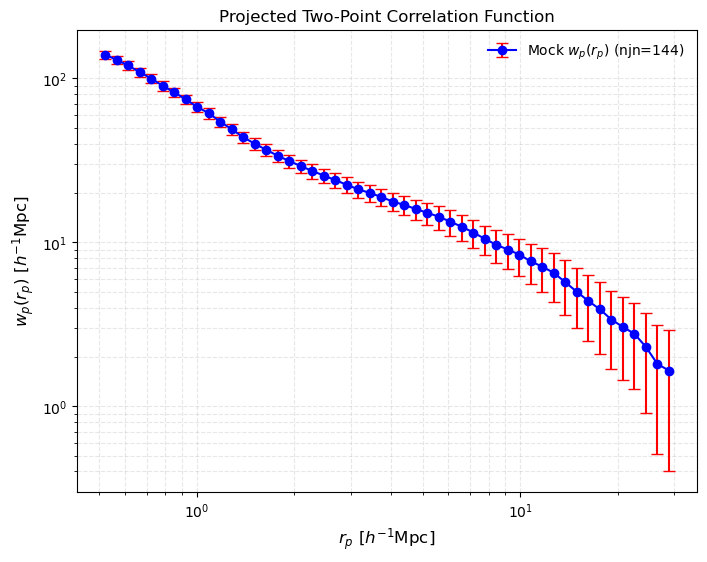

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Plot w_p(r_p) using the variables already in memory from your loop
plt.errorbar(rp_jk, wp_mean, yerr=diag_err, fmt='o-', 
             color='blue', ecolor='red', capsize=4, label=r'Mock $w_p(r_p)$ (njn=144)')

# w_p(r_p) requires a log-log scale 
plt.xscale('log')
plt.yscale('log')

# Standard axis labels
plt.xlabel(r'$r_p \ [h^{-1}{\rm Mpc}]$', fontsize=12)
plt.ylabel(r'$w_p(r_p) \ [h^{-1}{\rm Mpc}]$', fontsize=12)
plt.title('Projected Two-Point Correlation Function')

plt.legend(frameon=False)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()